In [1]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets

In [2]:
X.head(10)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States


In [3]:
y['income'].unique()

<StringArray>
['<=50K', '>50K', '<=50K.', '>50K.']
Length: 4, dtype: str

In [4]:
y['income'] = y['income'].replace({'<=50K.':'<=50K', '>50K.':'>50K'})

In [6]:
encoding_y = {'<=50K':0, '>50K':1}
y['income'] = y['income'].map(encoding_y)

In [7]:
print(f'Number of NA: {X.isna().any(axis=1).sum()}')

Number of NA: 1221


In [8]:
idx_na = X.index[X.isna().any(axis=1)]
X.dropna(inplace=True)
y.drop(idx_na, inplace=True)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

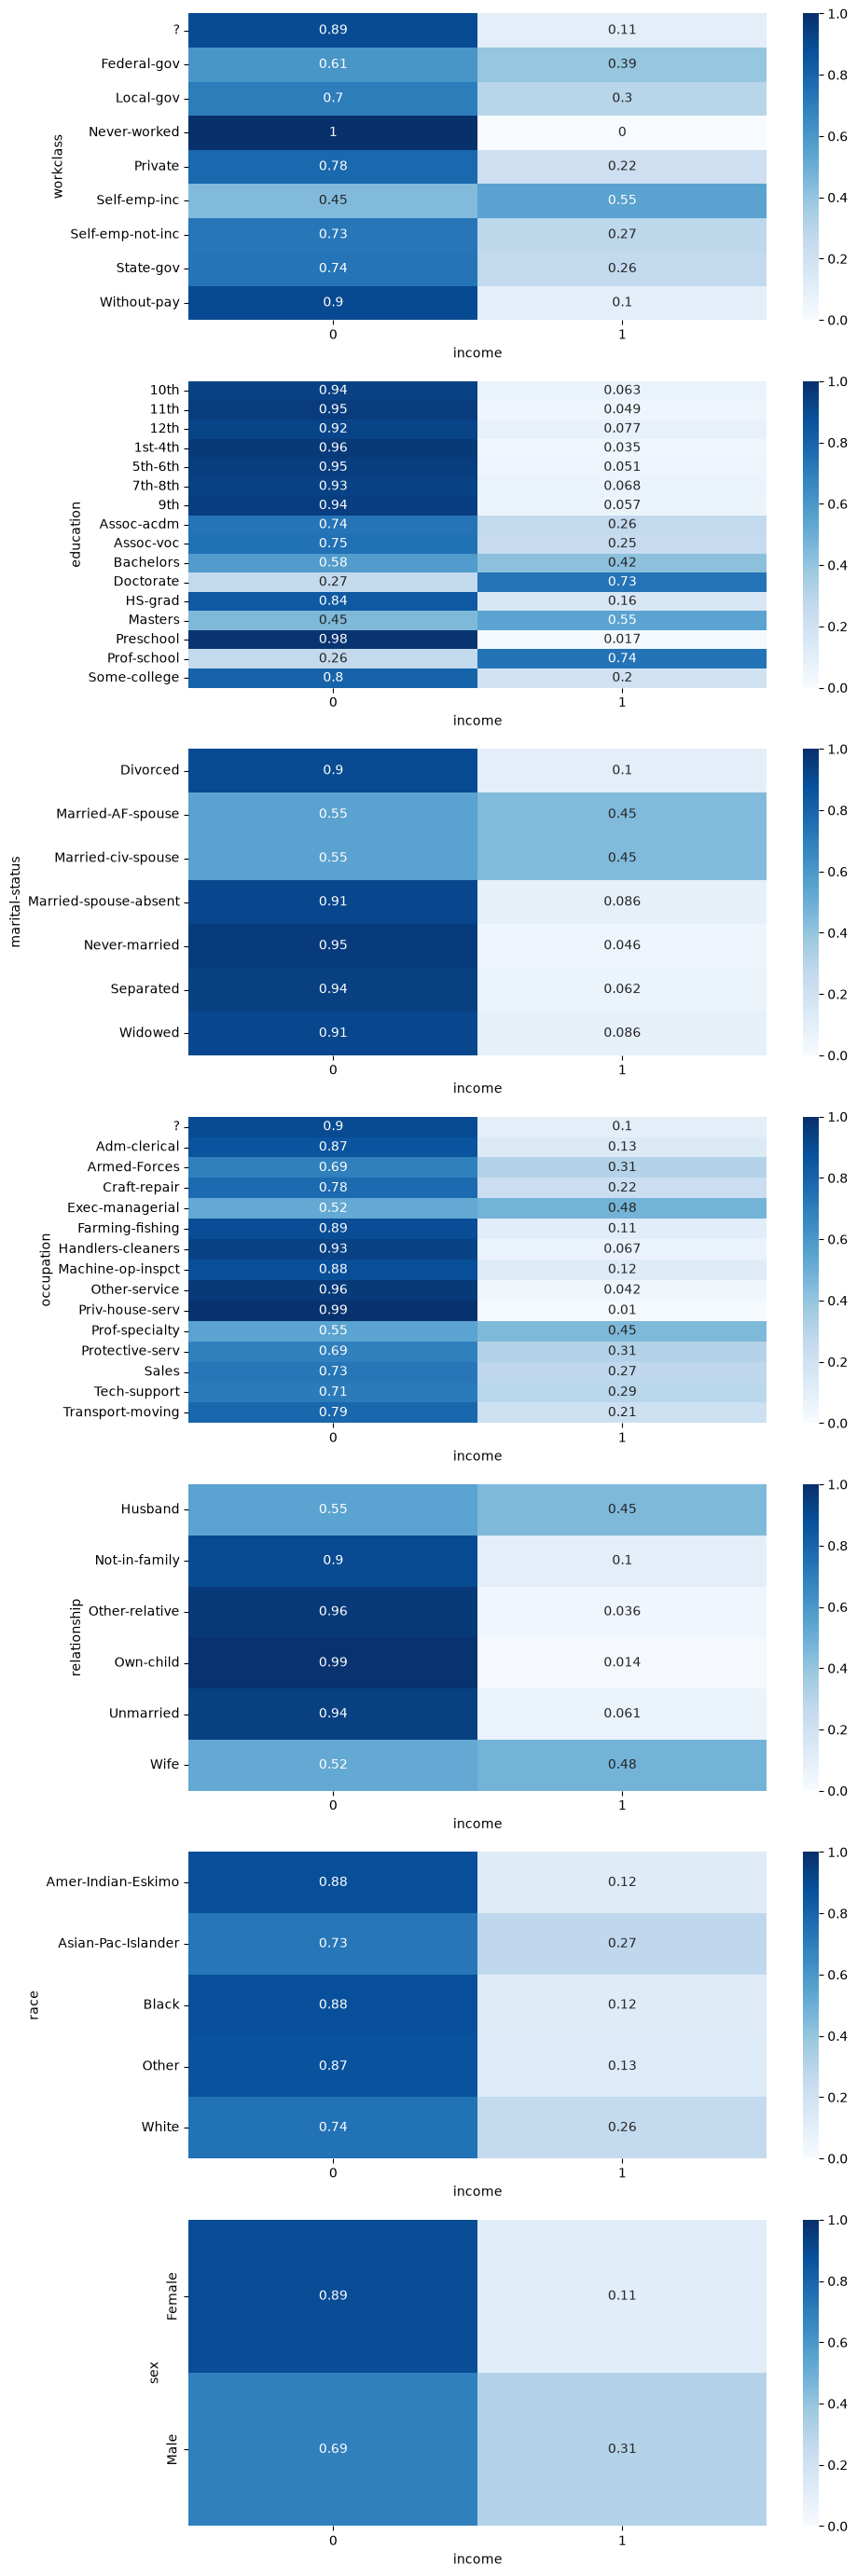

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['workclass', 'education', 'marital-status', 
        'occupation', 'relationship', 'race', 'sex']

fig, ax = plt.subplots(len(cols), 1, figsize = (10, 35))
i = 0
for i, col in enumerate(cols):
    ct = pd.crosstab(X_train[col], y_train['income'], normalize='index')
    sns.heatmap(ct, annot=True, cmap='Blues', vmin=0, vmax=1, ax=ax[i])
plt.show()

In [11]:
cols = ['workclass', 'education', 'marital-status', 
        'occupation', 'relationship', 'race', 'sex',
       'native-country']

for col in cols:
    encoding = (y_train['income'] == '>50K').groupby(X_train[col]).mean()
    X_train[col] = X_train[col].map(encoding)
    X_test[col] = X_test[col].map(encoding)

In [20]:
import optuna
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    max_depth = trial.suggest_int('max_depth', 50, 500)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 10)
    max_leaf_nodes = trial.suggest_int('max_leaf_nodes', 20, 500)

    tree = DecisionTreeClassifier(
        max_depth = max_depth,
        min_samples_split = min_samples_split,
        min_samples_leaf = min_samples_leaf,
        max_leaf_nodes = max_leaf_nodes,
        random_state = 42
    )

    score = cross_val_score(estimator = tree,
                            X = X_train, 
                            y = y_train, 
                            cv=4, scoring='accuracy').mean()

    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=500)
    

[I 2026-07-17 00:42:24,574] A new study created in memory with name: no-name-76de55f1-6f8a-40e0-8743-489e9b332b31
[I 2026-07-17 00:42:24,769] Trial 0 finished with value: 0.8286434271314573 and parameters: {'max_depth': 82, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_leaf_nodes': 371}. Best is trial 0 with value: 0.8286434271314573.
[I 2026-07-17 00:42:24,969] Trial 1 finished with value: 0.822894792104158 and parameters: {'max_depth': 393, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_leaf_nodes': 493}. Best is trial 0 with value: 0.8286434271314573.
[I 2026-07-17 00:42:25,151] Trial 2 finished with value: 0.8308483830323393 and parameters: {'max_depth': 364, 'min_samples_split': 19, 'min_samples_leaf': 2, 'max_leaf_nodes': 176}. Best is trial 2 with value: 0.8308483830323393.
[I 2026-07-17 00:42:25,334] Trial 3 finished with value: 0.8295884082318354 and parameters: {'max_depth': 118, 'min_samples_split': 11, 'min_samples_leaf': 1, 'max_leaf_nodes': 281}. Best is trial 

In [21]:
tree = DecisionTreeClassifier(**study.best_params)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score

accuracy_score(y_pred, y_test)

0.8301312335958005

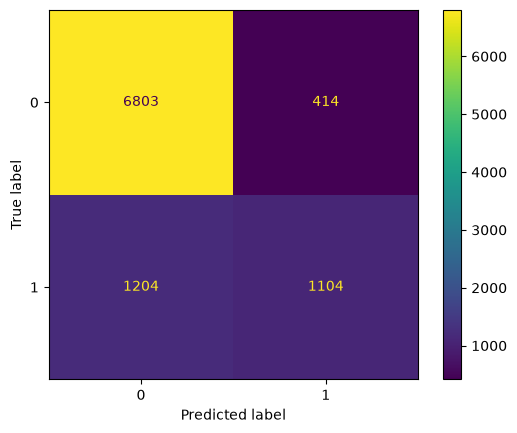

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [35]:
tree.predict_proba(X_test)[:, 0]

from sklearn.metrics import roc_curve

fpr, tpr, thr = roc_curve(y_test, tree.predict_proba(X_test)[:,0])

array([0.00000000e+00, 4.33275563e-04, 3.89948007e-03, 5.63258232e-03,
       1.47313692e-02, 3.29289428e-02, 4.28942808e-02, 4.37608319e-02,
       4.72270364e-02, 5.93587522e-02, 7.10571924e-02, 7.10571924e-02,
       7.84228769e-02, 9.48873484e-02, 9.61871750e-02, 1.03552860e-01,
       1.05285962e-01, 1.06152513e-01, 1.12218371e-01, 1.16117851e-01,
       1.34748700e-01, 1.42980936e-01, 1.59878683e-01, 1.64644714e-01,
       1.72876950e-01, 1.72876950e-01, 1.73743501e-01, 1.83708839e-01,
       2.28336222e-01, 2.51733102e-01, 2.54766031e-01, 2.60831889e-01,
       2.76863085e-01, 2.78162912e-01, 2.79896014e-01, 2.92461005e-01,
       3.36221837e-01, 3.38821490e-01, 3.50953206e-01, 3.88648180e-01,
       3.99046794e-01, 4.06845754e-01, 4.37175043e-01, 4.38474870e-01,
       4.85701906e-01, 4.87001733e-01, 4.96100520e-01, 5.00433276e-01,
       5.00866551e-01, 5.21663778e-01, 5.30329289e-01, 5.33362218e-01,
       5.36395147e-01, 5.51559792e-01, 5.97487002e-01, 5.99220104e-01,
      

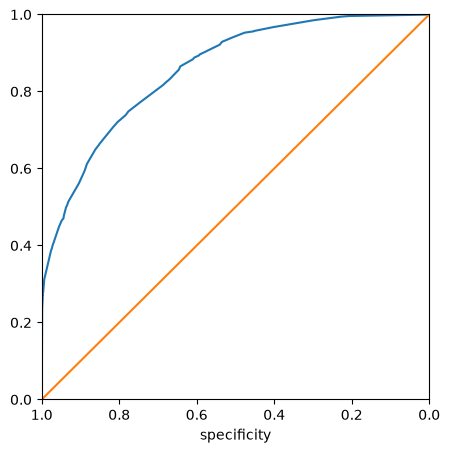

In [39]:
from sklearn.metrics import roc_curve

fpr, tpr, thr = roc_curve(y_test, tree.predict_proba(X_test)[:,1])
roc_df = pd.DataFrame({'recall':tpr, 'specificity': 1 - fpr})
ax = roc_df.plot(x='specificity', y='recall', figsize=(5,5), legend=False)
ax.set_ylim(0,1)
ax.set_xlim(1,0)
ax.plot((1,0),(0,1))